# 07 — Structural Graph Analysis

This notebook investigates how structural graph properties influence solver
performance on the Max-Cut benchmark instances.

The analysis first partitions the benchmark instances into three structural
categories:

1. Bipartite graphs.

2. Non-bipartite graphs containing triangles, used as a proxy for graphs with
   short odd cycles.

3. Non-bipartite triangle-free graphs, used as a proxy for graphs whose odd
   cycles are of length greater than or equal to five.

The notebook then evaluates the performance of DAv3c, DAv2, DAv3, and the
selected MQLib heuristics across these structural categories.

In addition, the analysis examines several structural graph properties,
including:

- Transitivity
- Cyclomatic number
- Average clustering coefficient
- Negative edge-weight ratio
- Bridge fraction

to better understand how graph topology and edge-weight structure relate to
solver behavior and optimization performance.

In [1]:
from pathlib import Path
import sys
import numpy as np
import pandas as pd

#project imports
sys.path.append(str(Path("../src/maxcut").resolve()))

%load_ext autoreload
%autoreload 2

import config as cfg
import utils

In [2]:
# import paths
PATH_BASELINE_DATASET= cfg.PROCESSED_DIR / 'baseline_dataset.csv'

In [3]:
df_baseline = pd.read_csv(PATH_BASELINE_DATASET)
df_baseline.head()

,name,nodes,edges,density,limit,has_leafs,int_only,size_cat,density_cat,heuristics_name,...,neg_edges_frac,neg_wt_sum,neg_wt_ratio,has_triangles,triangle_count,cyclomatic_number,transitivity,average_clustering,bridge_count,bridge_fraction
0,G55,4969,12498,0.001013,13.945,True,True,large,sparse,BURER2002,...,0.000000,0.0,0.000000,True,23,7530,0.001100,0.001189,180,0.014402
1,G56,4969,12498,0.001013,13.922,True,True,large,sparse,BURER2002,...,0.502160,-6276.0,0.502160,True,23,7530,0.001100,0.001189,180,0.014402
2,G57,5000,10000,0.000800,11.299,False,True,large,sparse,BURER2002,...,0.501900,-5019.0,0.501900,False,0,5001,0.000000,0.000000,0,0.000000
3,G58,5000,29570,0.002366,11.876,False,True,large,sparse,BURER2002,...,0.000000,0.0,0.000000,True,30784,24571,0.098091,0.326822,0,0.000000
4,G59,5000,29570,0.002366,15.875,False,True,large,sparse,BURER2002,...,0.498377,-14737.0,0.498377,True,30784,24571,0.098091,0.326822,0,0.000000


In [4]:
len(df_baseline)

3400

In [5]:
common_df = df_baseline.dropna(subset = cfg.SOLVERS)

In [6]:
common_df = utils.filter_main_instances(common_df)

In [7]:
len(common_df)

738

In [8]:
common_df['size_cat'].value_counts()

size_cat
medium    407
large     331
Name: count, dtype: int64

In [9]:
common_df['density_cat'].value_counts()

density_cat
sparse      450
balanced    197
dense        91
Name: count, dtype: int64

In [10]:
sparse_df = common_df[common_df['density_cat']== 'sparse']

In [11]:
sparse_df['size_cat'].value_counts()

size_cat
medium    279
large     171
Name: count, dtype: int64

In [12]:
sparse_df['heuristics_name'].value_counts()

heuristics_name
BURER2002    450
Name: count, dtype: int64

In [13]:
df_sub_filtered = sparse_df.copy()

In [14]:
df_sub_filtered["structure_group"] = np.select(
    [
        df_sub_filtered["bipartite"] == True,
        (df_sub_filtered["bipartite"] == False) & (df_sub_filtered["has_triangles"] == True),
        (df_sub_filtered["bipartite"] == False) & (df_sub_filtered["has_triangles"] == False),
    ],
    [
        "bipartite",
        "non_bipartite_with_triangles",
        "non_bipartite_triangle_free",
    ],
    default="other"
)

In [15]:
category_counts = df_sub_filtered["structure_group"].value_counts()

# reorder
category_counts = category_counts.reindex([
    "bipartite",
    "non_bipartite_with_triangles",
    "non_bipartite_triangle_free"
])

print(category_counts)

structure_group
bipartite                        82
non_bipartite_with_triangles    248
non_bipartite_triangle_free     120
Name: count, dtype: int64


In [16]:
df_sub_filtered['size_cat'].value_counts()

size_cat
medium    279
large     171
Name: count, dtype: int64

In [17]:
len(df_sub_filtered)

450

In [18]:
df_sub_filtered['structure_group'].value_counts()

structure_group
non_bipartite_with_triangles    248
non_bipartite_triangle_free     120
bipartite                        82
Name: count, dtype: int64

In [19]:
size_distribution = (
    df_sub_filtered
    .groupby(["structure_group", "size_cat"])
    .size()
    .unstack(fill_value=0)
)

# reorder rows
size_distribution = size_distribution.reindex([
    "bipartite",
    "non_bipartite_with_triangles",
    "non_bipartite_triangle_free"
])

# optional: reorder columns
size_distribution = size_distribution[["medium", "large"]]

print(size_distribution)

size_cat                      medium  large
structure_group                            
bipartite                         55     27
non_bipartite_with_triangles     145    103
non_bipartite_triangle_free       79     41


In [20]:
density_stats = (
    df_sub_filtered
    .groupby("structure_group")["density"]
    .agg(["mean", "median", "std", "min", "max"])
)

print(density_stats)

                                  mean    median       std       min       max
structure_group                                                               
bipartite                     0.001726  0.001293  0.001299  0.000500  0.005374
non_bipartite_triangle_free   0.003463  0.001586  0.006516  0.000455  0.039002
non_bipartite_with_triangles  0.023728  0.001878  0.034532  0.000316  0.099959


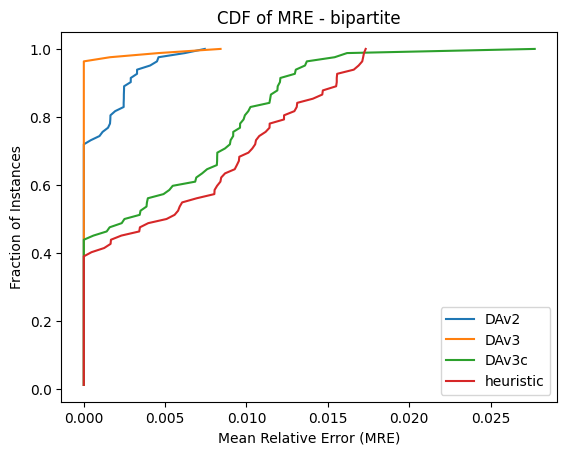

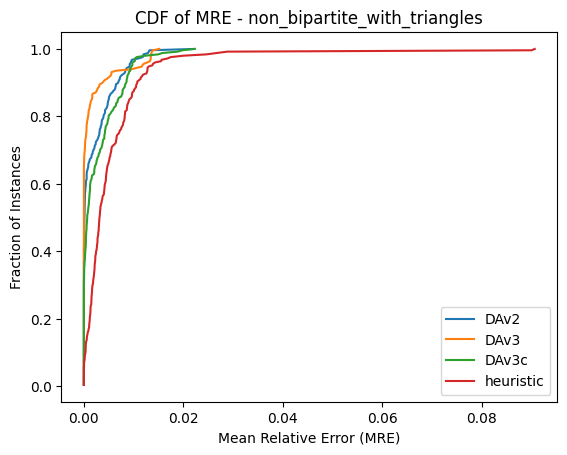

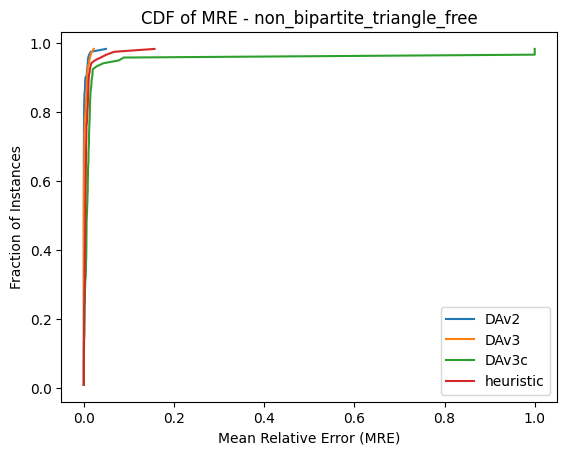

In [21]:
import numpy as np
import matplotlib.pyplot as plt

def plot_cdf(data, label):
    sorted_data = np.sort(data)
    yvals = np.arange(1, len(sorted_data)+1) / len(sorted_data)
    plt.plot(sorted_data, yvals, label=label)

groups = [
    "bipartite",
    "non_bipartite_with_triangles",
    "non_bipartite_triangle_free"
]


for g in groups:
    plt.figure()
    subset = df_sub_filtered[df_sub_filtered["structure_group"] == g]
    
    for s in cfg.SOLVERS:
        mre = (subset["baseline_objective"] - subset[s]) / subset["baseline_objective"]
        plot_cdf(mre, s)
    
    plt.xlabel("Mean Relative Error (MRE)")
    plt.ylabel("Fraction of Instances")
    plt.title(f"CDF of MRE - {g}")
    plt.legend()
    plt.show()

In [22]:
solver_col_map = {
    "DAv3c": ("DAv3c", "is_optimal_dav3c"),
    "DAv3": ("DAv3", "is_optimal_dav3"),
    "DAv2": ("DAv2", "is_optimal_dav2"),
    "BURER2002": ("heuristic", "is_optimal_heu"),
}

df_sub_filtered = df_sub_filtered.copy()

for best_name, (_, out_col) in solver_col_map.items():

    df_sub_filtered[out_col] = (
        df_sub_filtered["best_solvers"]
        .astype(str)
        .apply(lambda x: best_name in x)
    )

success_table = (
    df_sub_filtered
    .groupby("structure_group")[
        [v[1] for v in solver_col_map.values()]
    ]
    .mean()
    * 100
)

success_table

,is_optimal_dav3c,is_optimal_dav3,is_optimal_dav2,is_optimal_heu
structure_group,,,,
bipartite,43.902439,97.560976,67.073171,34.146341
non_bipartite_triangle_free,8.333333,51.666667,63.333333,5.833333
non_bipartite_with_triangles,24.193548,77.419355,33.064516,0.403226


In [23]:
plot_df = success_table.copy()

plot_df = plot_df.rename(columns={
    "is_optimal_dav3c": "DAv3c",
    "is_optimal_dav3": "DAv3",
    "is_optimal_dav2": "DAv2",
    "is_optimal_heu": "Heuristic"
})

# Ensure correct order
plot_df = plot_df.loc[
    ["bipartite", "non_bipartite_with_triangles", "non_bipartite_triangle_free"]
]

plot_df = plot_df.round(2)
print(plot_df)

                              DAv3c   DAv3   DAv2  Heuristic
structure_group                                             
bipartite                     43.90  97.56  67.07      34.15
non_bipartite_with_triangles  24.19  77.42  33.06       0.40
non_bipartite_triangle_free    8.33  51.67  63.33       5.83


In [24]:
from statsmodels.stats.proportion import proportion_confint

results = []

for structure, group in df_sub_filtered.groupby("structure_group"):

    n = len(group)

    row = {
        "structure_group": structure,
        "n": n
    }

    for solver_name, (_, col) in solver_col_map.items():

        successes = group[col].sum()

        proportion = successes / n

        # Wilson confidence interval
        ci_low, ci_high = proportion_confint(
            successes,
            n,
            alpha=0.05,
            method="wilson"
        )

        row[f"{solver_name}_pct"] = proportion * 100
        row[f"{solver_name}_ci_low"] = ci_low * 100
        row[f"{solver_name}_ci_high"] = ci_high * 100

    results.append(row)

ci_table = pd.DataFrame(results)

ci_table

,structure_group,n,DAv3c_pct,DAv3c_ci_low,DAv3c_ci_high,DAv3_pct,DAv3_ci_low,DAv3_ci_high,DAv2_pct,DAv2_ci_low,DAv2_ci_high,BURER2002_pct,BURER2002_ci_low,BURER2002_ci_high
0,bipartite,82,43.902439,33.673538,54.677079,97.560976,91.536622,99.328563,67.073171,56.338388,76.279883,34.146341,24.799345,44.912260
1,non_bipartite_triangle_free,120,8.333333,4.589365,14.662232,51.666667,42.813580,60.416356,63.333333,54.422424,71.417065,5.833333,2.854101,11.552592
2,non_bipartite_with_triangles,248,24.193548,19.283391,29.890982,77.419355,71.820309,82.181919,33.064516,27.506866,39.138817,0.403226,0.071215,2.248284


In [22]:
transitivity_table = utils.compare_structure_metric(
    df_sub_filtered,
    "transitivity"
)

transitivity_table

,structure_group,count,min,q25,median,q75,max,mean,std,unique_count
0,non_bipartite_with_triangles,248,0.0003,0.0096,0.0432,0.1056,0.7982,0.0959,0.1445,240
1,non_bipartite_triangle_free,120,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,1


In [23]:
cyclomatic_table = utils.compare_structure_metric(
    df_sub_filtered,
    "cyclomatic_number"
)

cyclomatic_table

,structure_group,count,min,q25,median,q75,max,mean,std,unique_count
0,non_bipartite_with_triangles,248,67,2849.50,10001.0,267441.0,2359134,157601.7177,304570.2546,226
1,non_bipartite_triangle_free,120,18,3861.25,6737.0,14289.0,276099,16033.7667,35128.5538,87


In [24]:
clustering_table = utils.compare_structure_metric(
    df_sub_filtered,
    "average_clustering"
)

clustering_table

,structure_group,count,min,q25,median,q75,max,mean,std,unique_count
0,non_bipartite_with_triangles,248,0.0001,0.0342,0.1064,0.3844,0.9599,0.2063,0.2003,240
1,non_bipartite_triangle_free,120,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,1


In [25]:
bridge_table = utils.compare_structure_metric(
    df_sub_filtered,
    "bridge_fraction"
)

bridge_table

,structure_group,count,min,q25,median,q75,max,mean,std,unique_count
0,non_bipartite_with_triangles,248,0.0,0.0,0.0014,0.1157,0.7766,0.0825,0.1432,125
1,non_bipartite_triangle_free,120,0.0,0.0,0.0000,0.0000,0.8832,0.0152,0.0939,5


In [26]:
neg_edge_table = utils.compare_structure_metric(
    df_sub_filtered,
    "neg_edges_frac"
)

neg_edge_table

,structure_group,count,min,q25,median,q75,max,mean,std,unique_count
0,non_bipartite_with_triangles,248,0.0,0.0,0.0,0.0246,0.6929,0.0723,0.1605,99
1,non_bipartite_triangle_free,120,0.0,0.0,0.0,0.0674,0.8449,0.1089,0.2096,38
